<a href="https://colab.research.google.com/github/UsamahPutraFirdaus/Fraud_Detection/blob/main/%5BClustering%5D_Submission_Akhir_BMLP_Usamah_Putra_Firdaus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [ ]:
url = "https://drive.google.com/file/d/16Apdk1JfL_reiNNAN2rYtcqBYB_nxrk3/view?usp=drive_link"
file_id = url.split('/')[-2]
download_url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(download_url)
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [ ]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [ ]:
df.tail()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22
2511,TX002512,AC00009,243.08,2023-02-14 16:21:23,Credit,Jacksonville,D000215,59.127.135.25,M041,Online,24,Student,93,1,131.25,2024-11-04 08:07:49


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [ ]:
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2512,2512,2512.000000,2512,2512,2512,2512,2512,2512,2512,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512
unique,2512,495,NaN,2512,2,43,681,592,100,3,NaN,4,NaN,NaN,NaN,360
top,TX002496,AC00460,NaN,2023-04-03 16:07:53,Debit,Fort Worth,D000548,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,1,12,NaN,1,1944,70,9,13,45,868,NaN,657,NaN,NaN,NaN,16
mean,NaN,NaN,297.593778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.673965,NaN,119.643312,1.124602,5114.302966,NaN
std,NaN,NaN,291.946243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.792198,NaN,69.963757,0.602662,3900.942499,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.885000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.370000,NaN
50%,NaN,NaN,211.140000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.500000,1.000000,4735.510000,NaN
75%,NaN,NaN,414.527500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7678.820000,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

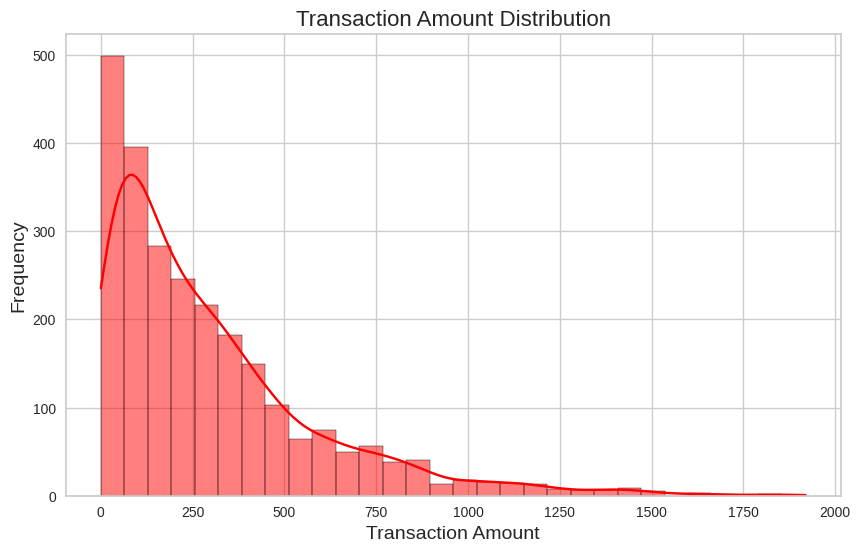

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TransactionAmount'], kde=True, bins=30, color='red')
plt.title('Transaction Amount Distribution', fontsize=16)
plt.xlabel('Transaction Amount', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

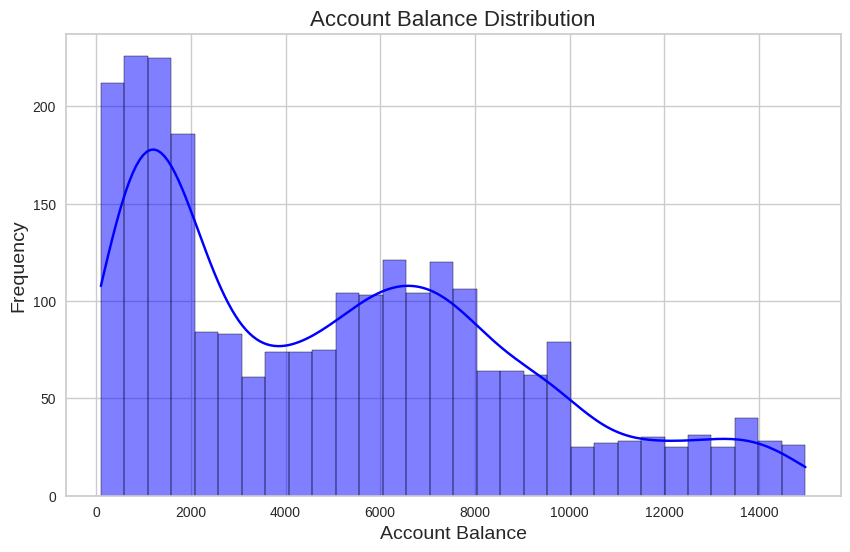

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['AccountBalance'], kde=True, bins=30, color='blue')
plt.title('Account Balance Distribution', fontsize=16)
plt.xlabel('Account Balance', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

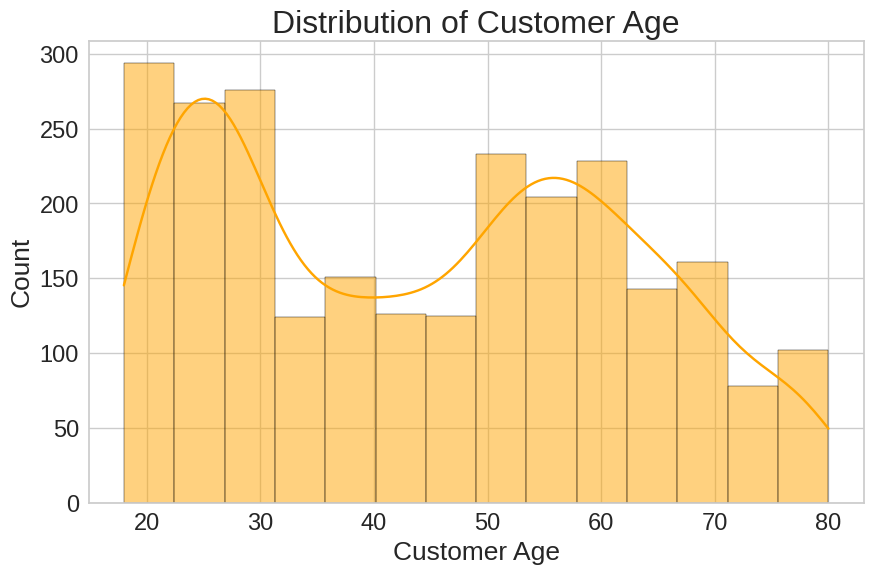

In [ ]:
plt.figure(figsize=(10,6))

plt.xlabel('Customer Age', fontsize=19)
plt.ylabel('Count', fontsize=19)

plt.yticks(fontsize=17)
plt.xticks(fontsize=17)

plt.title('Distribution of Customer Age', fontsize=23)

sns.histplot(data = df, x=df['CustomerAge'], kde=True, color='orange')

plt.show()

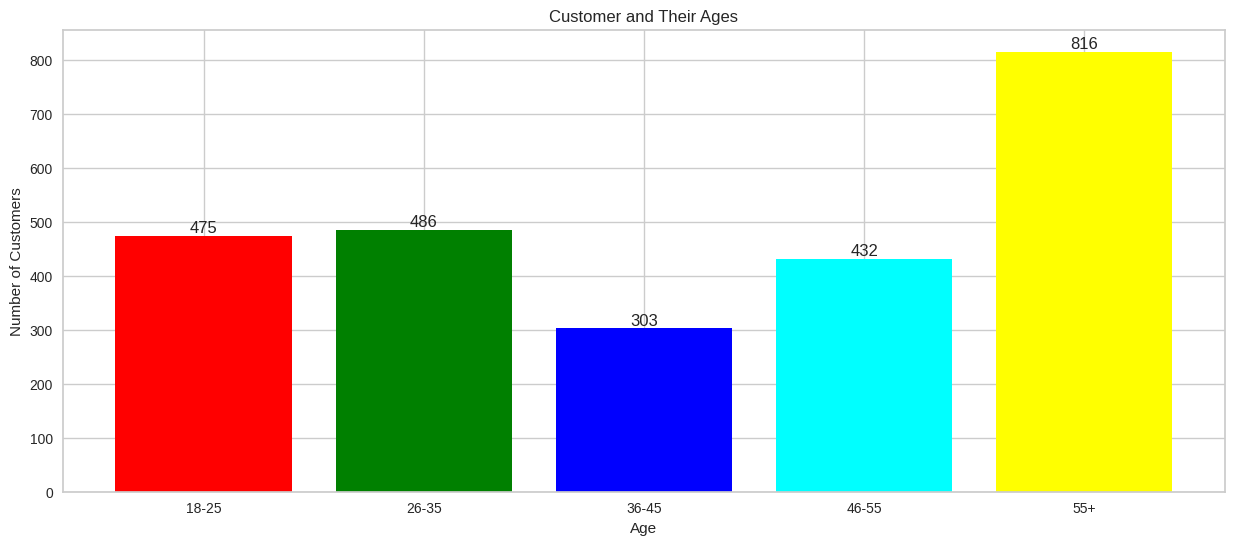

In [ ]:
age18_25 = df.CustomerAge[(df.CustomerAge >= 18) & (df.CustomerAge <= 25)]
age26_35 = df.CustomerAge[(df.CustomerAge >= 26) & (df.CustomerAge <= 35)]
age36_45 = df.CustomerAge[(df.CustomerAge >= 36) & (df.CustomerAge <= 45)]
age46_55 = df.CustomerAge[(df.CustomerAge >= 46) & (df.CustomerAge <= 55)]
age55above = df.CustomerAge[df.CustomerAge >= 56]

x = ['18-25', '26-35', '36-45', '46-55', '55+']
y = [len(age18_25.values), len(age26_35.values), len(age36_45.values), len(age46_55.values), len(age55above.values)]

# Membuat bar chart untuk distribusi usia pelanggan
plt.figure(figsize=(15, 6))
plt.bar(x, y, color=['red', 'green', 'blue', 'cyan', 'yellow'])
plt.title("Customer and Their Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# Menambahkan label jumlah pelanggan di atas setiap bar
for i in range(len(x)):
  plt.text(i, y[i], y[i], ha='center', va='bottom')

plt.show()

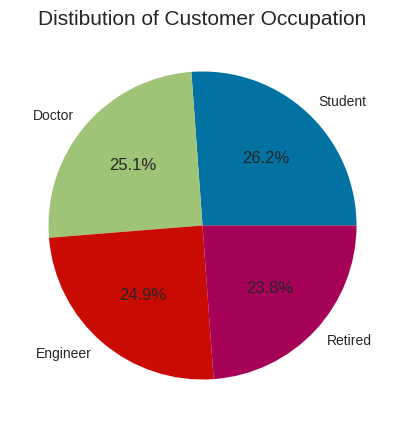

In [ ]:
plt.figure(figsize=(10, 5))
plt.pie(df['CustomerOccupation'].value_counts(), labels=df['CustomerOccupation'].value_counts().index, autopct='%1.1f%%')
plt.title('Distibution of Customer Occupation', fontsize=15)
plt.show()

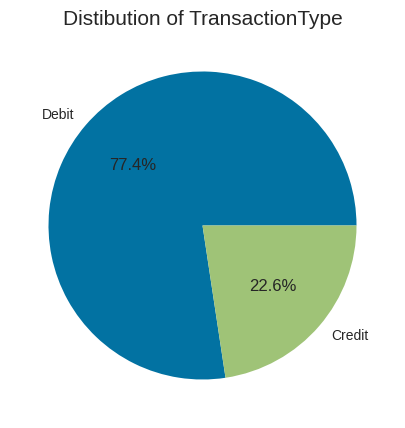

In [ ]:
plt.figure(figsize=(10, 5))
plt.pie(df['TransactionType'].value_counts(), labels=df['TransactionType'].value_counts().index, autopct='%1.1f%%')
plt.title('Distibution of TransactionType', fontsize=15)
plt.show()

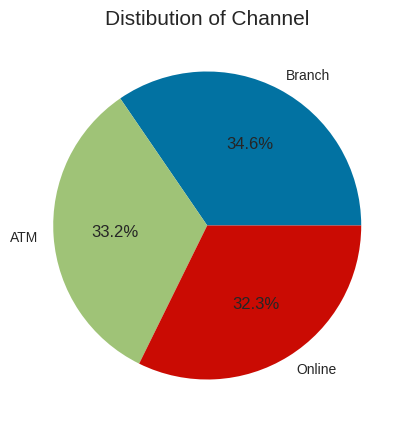

In [ ]:
plt.figure(figsize=(10, 5))
plt.pie(df['Channel'].value_counts(), labels=df['Channel'].value_counts().index, autopct='%1.1f%%')
plt.title('Distibution of Channel', fontsize=15)
plt.show()

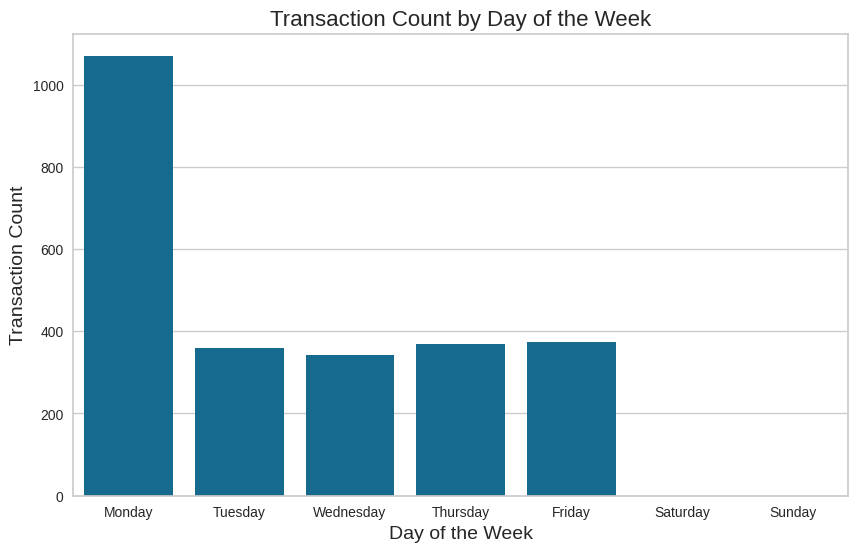

In [ ]:
date_columns = ['TransactionDate', 'PreviousTransactionDate']

for column in date_columns:
  df[column] = pd.to_datetime(df[column])

df['TransactionDayOfWeek'] = df['TransactionDate'].dt.day_name()


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='TransactionDayOfWeek', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Transaction Count by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Transaction Count', fontsize=14)
plt.show()

<ipython-input-15-d2d8b5e455c7>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=all_locations.index, x=all_locations.values, palette='viridis')


Text(0, 0.5, 'Location')

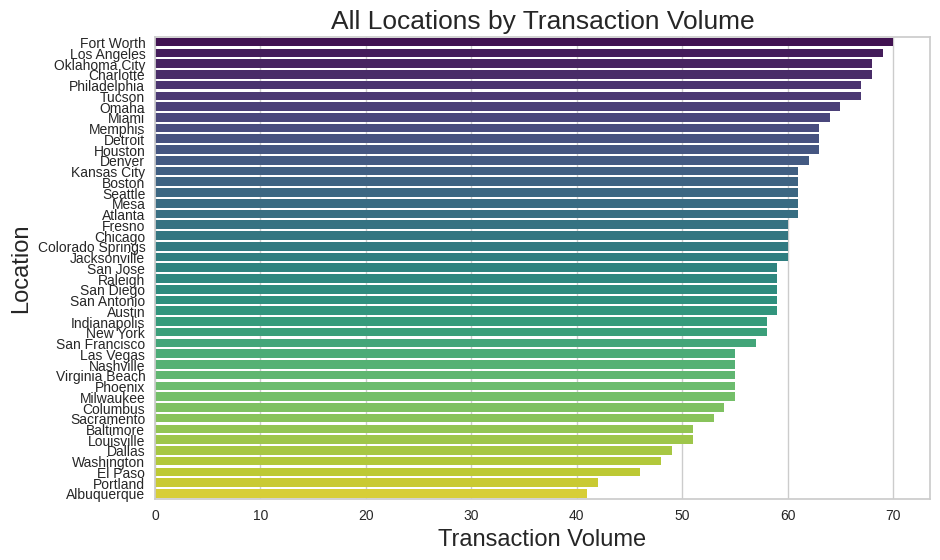

In [ ]:
all_locations = df['Location'].value_counts().head(43)

plt.figure(figsize=(10,6))
sns.barplot(y=all_locations.index, x=all_locations.values, palette='viridis')
plt.title('All Locations by Transaction Volume', fontsize=19)
plt.xlabel('Transaction Volume', fontsize=17)
plt.ylabel('Location', fontsize=17)

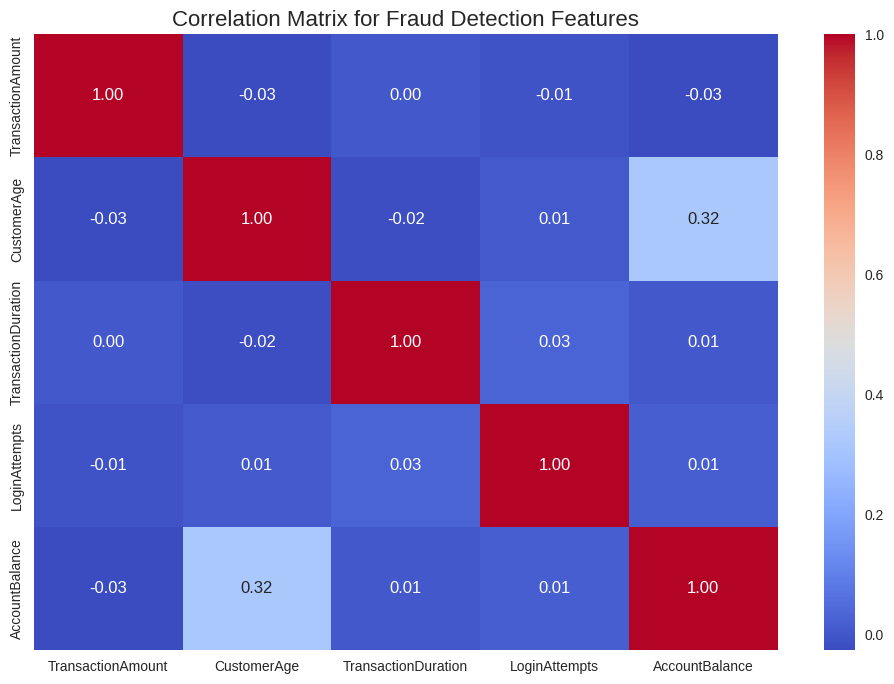

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Creating the correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Fraud Detection Features', fontsize=16)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

## a. Handling Missing Value & Duplicated

In [ ]:
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [ ]:
print('Jumlah Data Duplicate: ', df.duplicated().sum())

Jumlah Data Duplicate:  0


Dataset yang digunakan sudah bersih, tidak memiliki missing value dan duplikasi data

## b. Feature Engineering

In [ ]:
df['AmountToBalanceRatio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1e-9)  # Prevent division by zero
df['AmountPerLogin'] = df['TransactionAmount'] / (df['LoginAttempts'] + 1e-9)
df['TransactionHour'] = df['TransactionDate'].dt.hour  # Extract hour
df['TimeOfDay'] = pd.cut(df['TransactionHour'], bins=[0, 6, 12, 18, 24], labels=['Night', 'Morning', 'Afternoon', 'Evening'])
df['TimeOfDay'] = df['TimeOfDay'].cat.codes  # Encode TimeOfDay as numeric

## c. Menghapus Kolom yang tidak digunakan

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   object        
 1   AccountID                2512 non-null   object        
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[ns]
 4   TransactionType          2512 non-null   object        
 5   Location                 2512 non-null   object        
 6   DeviceID                 2512 non-null   object        
 7   IP Address               2512 non-null   object        
 8   MerchantID               2512 non-null   object        
 9   Channel                  2512 non-null   object        
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   object        
 12  TransactionDuration      2512 non-

In [ ]:
df = df.drop(['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'TransactionDate', 'PreviousTransactionDate'], axis=1)

In [ ]:
df.columns

Index(['TransactionAmount', 'TransactionType', 'Location', 'Channel',
       'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'TransactionDayOfWeek',
       'AmountToBalanceRatio', 'AmountPerLogin', 'TransactionHour',
       'TimeOfDay'],
      dtype='object')

## d. Encoder Data Kategorikal

In [ ]:
# Pilih fitur kategorikal
categorical_features = df.select_dtypes(include=['object']).columns

# Lakukan encoding dengan LabelEncoder
label_encoders = {}

for kolom in categorical_features:
    le = LabelEncoder()
    df[kolom] = le.fit_transform(df[kolom])  # Pastikan hasil encoding langsung masuk ke DataFrame
    df[kolom] = df[kolom].astype(int)  # Konversi eksplisit ke integer
    label_encoders[kolom] = le  # Simpan encoder jika diperlukan nanti

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionAmount     2512 non-null   float64
 1   TransactionType       2512 non-null   int64  
 2   Location              2512 non-null   int64  
 3   Channel               2512 non-null   int64  
 4   CustomerAge           2512 non-null   int64  
 5   CustomerOccupation    2512 non-null   int64  
 6   TransactionDuration   2512 non-null   int64  
 7   LoginAttempts         2512 non-null   int64  
 8   AccountBalance        2512 non-null   float64
 9   TransactionDayOfWeek  2512 non-null   int64  
 10  AmountToBalanceRatio  2512 non-null   float64
 11  AmountPerLogin        2512 non-null   float64
 12  TransactionHour       2512 non-null   int32  
 13  TimeOfDay             2512 non-null   int8   
dtypes: float64(4), int32(1), int64(8), int8(1)
memory usage: 247.9 KB


## e. Handling Outliers

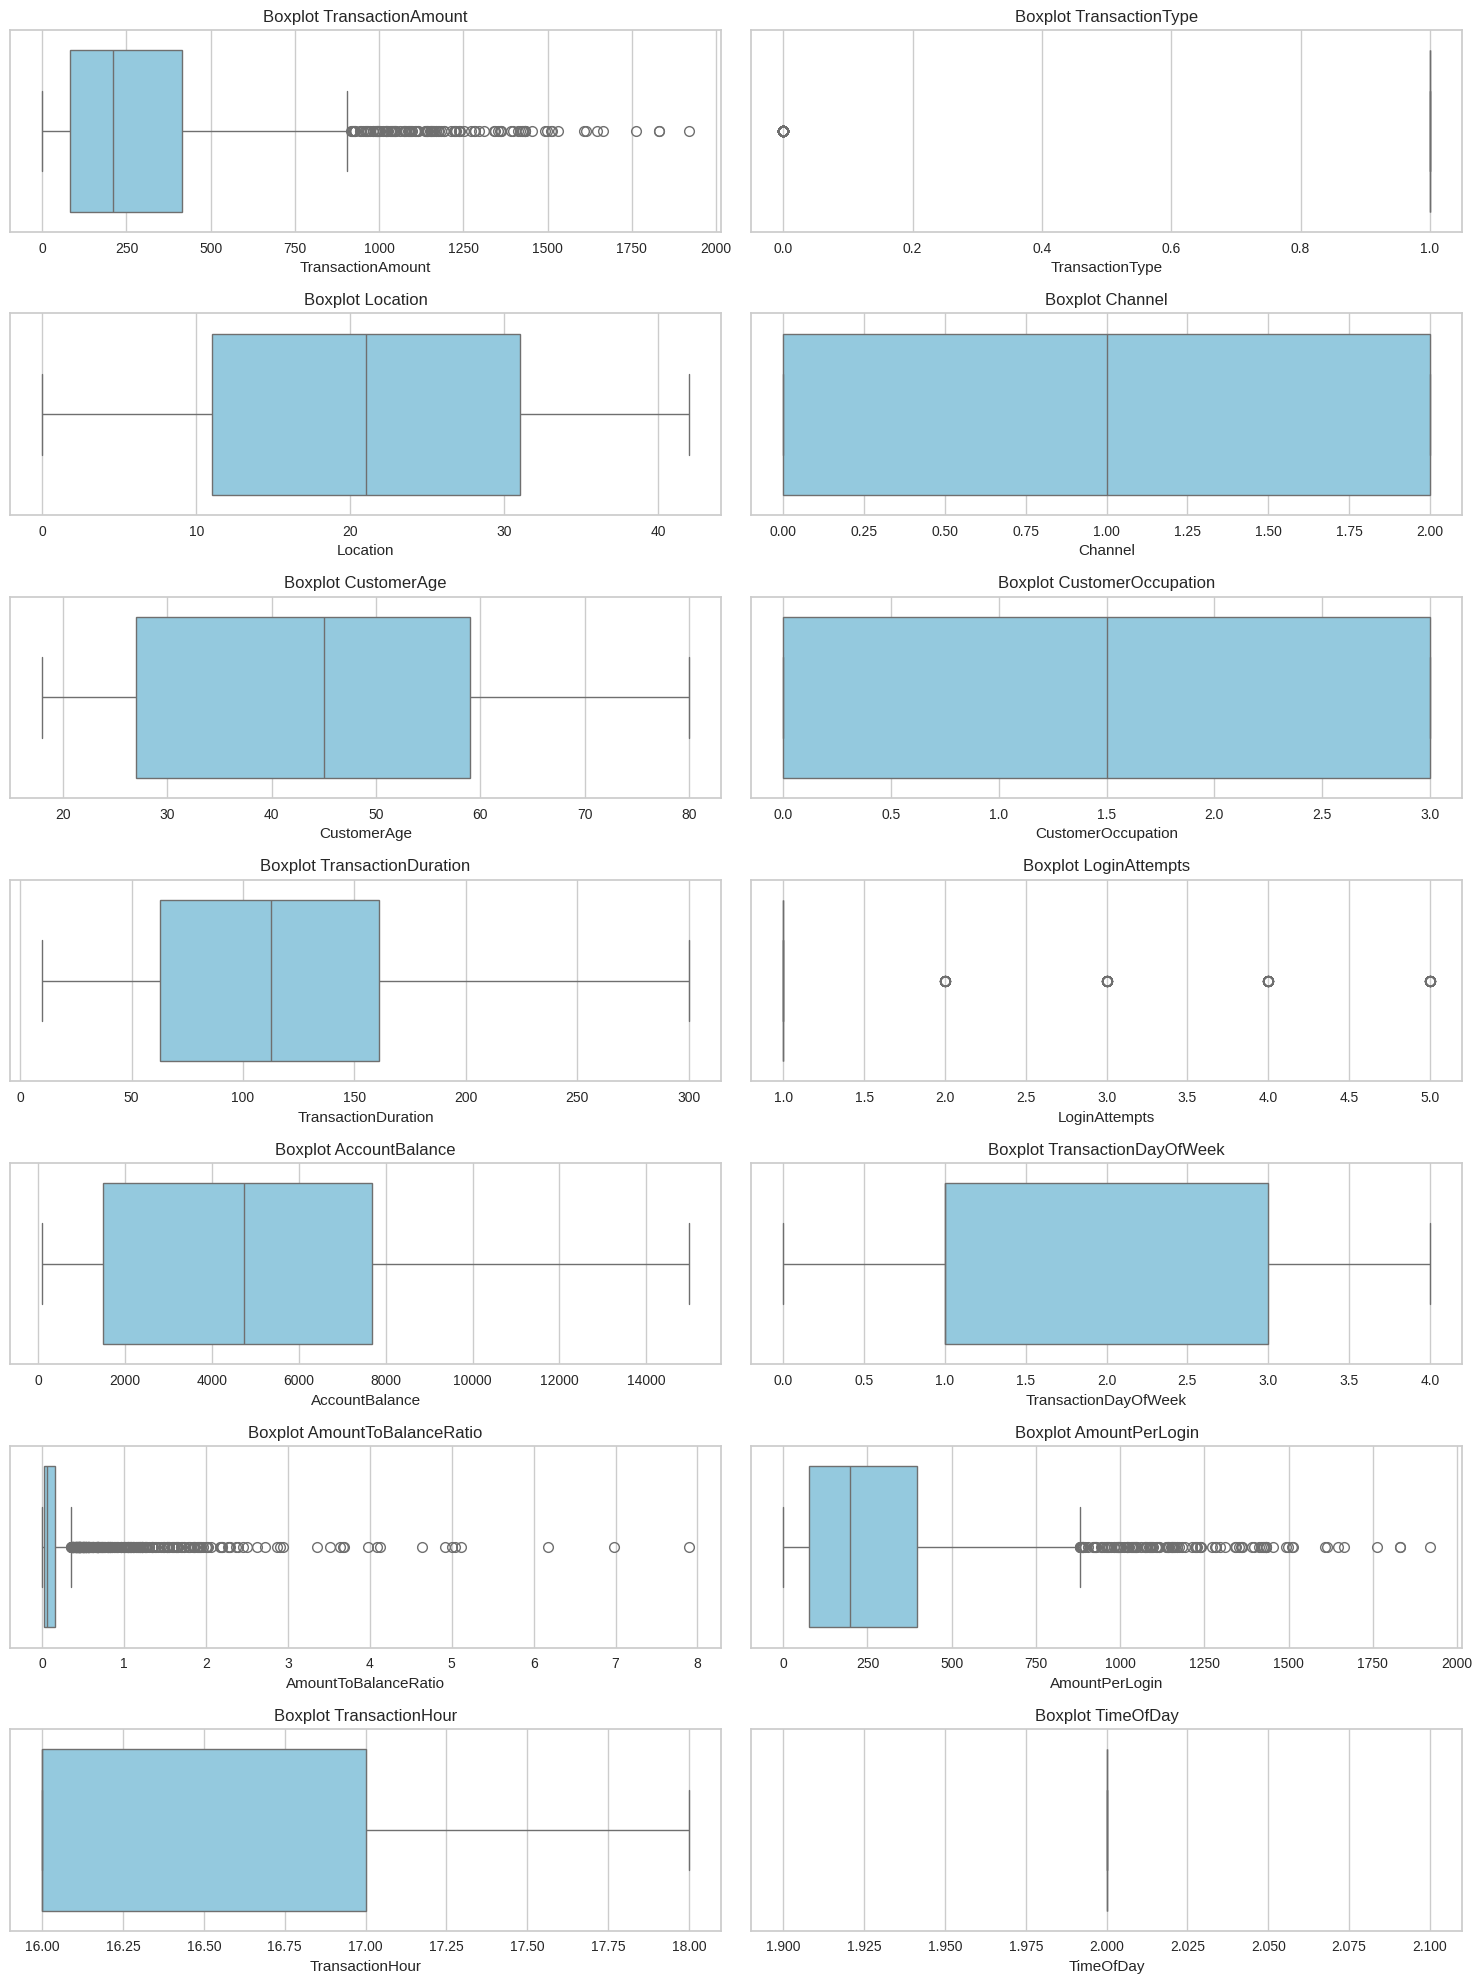

In [ ]:
numeric_cols = df.select_dtypes(include=['number'])

num_cols = len(numeric_cols.columns)
rows = (num_cols // 2) + (num_cols % 2)

fig, axes = plt.subplots(rows, 2, figsize=(15, 20))

if rows == 1:
    axes = [axes]

# Loop untuk membuat boxplot
for ax, (label, data) in zip(axes.flat, numeric_cols.items()):
    sns.boxplot(x=data, color='skyblue', ax=ax)
    ax.set_title(f"Boxplot {label}")
    ax.set_xlabel(label)

for i in range(num_cols, len(axes.flat)):
    fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.show()

Dari hasil visualisasi boxplot, terdapat cukup banyak outliers yang terdeteksi pada kolom TransactionAmount dan LoginAttemtps. Namun karena data tersebut memiliki peran penting dalam clustering dan fraud detection, sehingga akan berdampal buruk dalam melakukan analisis lebih lanjut maka dari itu saya biarkan outliers tersebut

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [ ]:
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDayOfWeek,AmountToBalanceRatio,AmountPerLogin,TransactionHour,TimeOfDay
0,14.09,1,36,0,70,0,81,1,5112.21,3,0.002756,14.09,16,2
1,376.24,1,15,0,68,0,141,1,13758.91,3,0.027345,376.24,16,2
2,126.29,1,23,2,19,3,56,1,1122.35,1,0.112523,126.29,18,2
3,184.50,1,33,2,26,3,25,1,8569.06,0,0.021531,184.50,16,2
4,13.45,0,1,2,26,3,198,1,7429.40,1,0.001810,13.45,17,2


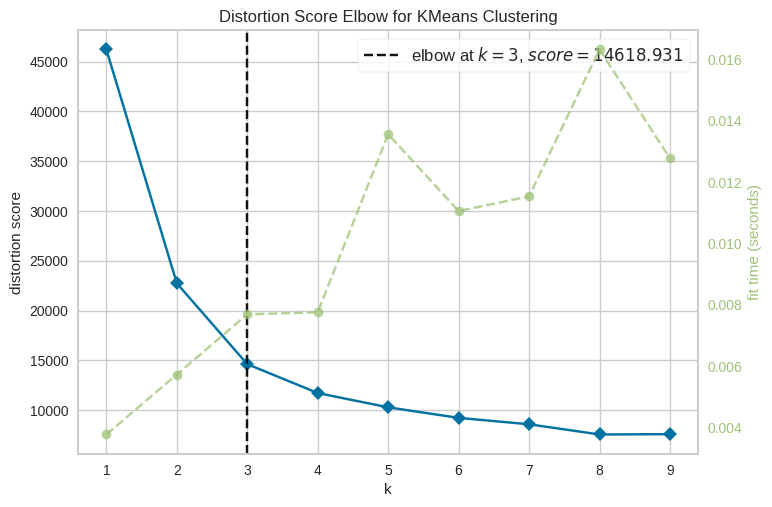

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Step 1: Select features
features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
            'AccountBalance', 'LoginAttempts', 'AmountToBalanceRatio',
            'AmountPerLogin', 'TransactionHour', 'TimeOfDay']
X = df[features]

# Step 2: Scaling
scaler = RobustScaler()  # Reduce the effect of outliers
X_scaled = scaler.fit_transform(X)

# Step 3: Dimensionality Reduction
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Optimize K-Means Clustering
cluster_range = range(2, 10)
silhouette_scores = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=300, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, labels)
    silhouette_scores.append(sil_score)

# Step 5: Optimal Clustering Value
kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(1, 10))
visualizer.fit(X_scaled)
visualizer.show()

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

In [ ]:
# Step 6: Apply Optimal K-Means
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, max_iter=300, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
df['Cluster'] = kmeans_labels

# Step 7: Evaluate Clustering
sil_score = silhouette_score(X_pca, kmeans_labels)
print(f"Optimal K-Means Silhouette Score: {sil_score:.2f}")

# Step 8: Detect Anomalies (Dynamic Threshold)
distances = np.linalg.norm(X_pca - kmeans.cluster_centers_[kmeans_labels], axis=1)
mean_distance = distances.mean()
std_distance = distances.std()
threshold = mean_distance + 2 * std_distance  # Points beyond 2 standard deviations
df['Potential_Fraud'] = distances > threshold

# Step 9: Output Results
frauds = df[df['Potential_Fraud']]
print(f"Number of potential frauds detected (K-Means): {len(frauds)}")

Optimal K-Means Silhouette Score: 0.77
Number of potential frauds detected (K-Means): 115


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [ ]:
#Type your code here

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

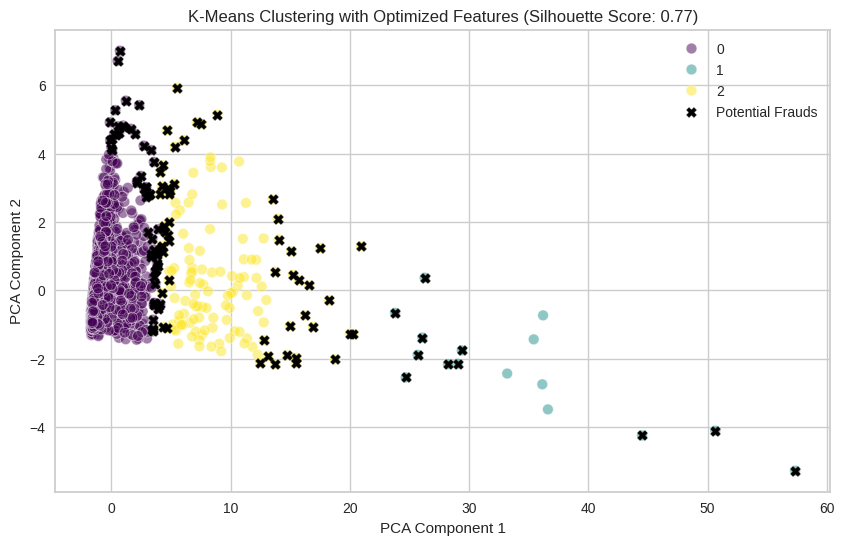

In [ ]:
# Step 10: Visualize Results
pca_2d = PCA(n_components=2)
reduced_data = pca_2d.fit_transform(X_pca)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=kmeans_labels, palette='viridis', s=60, alpha=0.5)
plt.scatter(reduced_data[distances > threshold, 0], reduced_data[distances > threshold, 1],
            color='black', s=50, label='Potential Frauds', marker='X')
plt.title(f'K-Means Clustering with Optimized Features (Silhouette Score: {sil_score:.2f})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

In [ ]:
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDayOfWeek,AmountToBalanceRatio,AmountPerLogin,TransactionHour,TimeOfDay,Cluster,Potential_Fraud
0,14.09,1,36,0,70,0,81,1,5112.21,3,0.002756,14.09,16,2,0,False
1,376.24,1,15,0,68,0,141,1,13758.91,3,0.027345,376.24,16,2,0,False
2,126.29,1,23,2,19,3,56,1,1122.35,1,0.112523,126.29,18,2,0,False
3,184.50,1,33,2,26,3,25,1,8569.06,0,0.021531,184.50,16,2,0,False
4,13.45,0,1,2,26,3,198,1,7429.40,1,0.001810,13.45,17,2,0,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionAmount     2512 non-null   float64
 1   TransactionType       2512 non-null   int64  
 2   Location              2512 non-null   int64  
 3   Channel               2512 non-null   int64  
 4   CustomerAge           2512 non-null   int64  
 5   CustomerOccupation    2512 non-null   int64  
 6   TransactionDuration   2512 non-null   int64  
 7   LoginAttempts         2512 non-null   int64  
 8   AccountBalance        2512 non-null   float64
 9   TransactionDayOfWeek  2512 non-null   int64  
 10  AmountToBalanceRatio  2512 non-null   float64
 11  AmountPerLogin        2512 non-null   float64
 12  TransactionHour       2512 non-null   int32  
 13  TimeOfDay             2512 non-null   int8   
 14  Cluster               2512 non-null   int32  
 15  Potential_Fraud      

In [ ]:
for kolom in categorical_features:
    df[kolom] = label_encoders[kolom].inverse_transform(df[kolom])

df.info()  # Periksa apakah data sudah kembali ke bentuk semula
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionAmount     2512 non-null   float64
 1   TransactionType       2512 non-null   object 
 2   Location              2512 non-null   object 
 3   Channel               2512 non-null   object 
 4   CustomerAge           2512 non-null   int64  
 5   CustomerOccupation    2512 non-null   object 
 6   TransactionDuration   2512 non-null   int64  
 7   LoginAttempts         2512 non-null   int64  
 8   AccountBalance        2512 non-null   float64
 9   TransactionDayOfWeek  2512 non-null   object 
 10  AmountToBalanceRatio  2512 non-null   float64
 11  AmountPerLogin        2512 non-null   float64
 12  TransactionHour       2512 non-null   int32  
 13  TimeOfDay             2512 non-null   int8   
 14  Cluster               2512 non-null   int32  
 15  Potential_Fraud      

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDayOfWeek,AmountToBalanceRatio,AmountPerLogin,TransactionHour,TimeOfDay,Cluster,Potential_Fraud
0,14.09,Debit,San Diego,ATM,70,Doctor,81,1,5112.21,Tuesday,0.002756,14.09,16,2,0,False
1,376.24,Debit,Houston,ATM,68,Doctor,141,1,13758.91,Tuesday,0.027345,376.24,16,2,0,False
2,126.29,Debit,Mesa,Online,19,Student,56,1,1122.35,Monday,0.112523,126.29,18,2,0,False
3,184.50,Debit,Raleigh,Online,26,Student,25,1,8569.06,Friday,0.021531,184.50,16,2,0,False
4,13.45,Credit,Atlanta,Online,26,Student,198,1,7429.40,Monday,0.001810,13.45,17,2,0,False


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

In [ ]:
X_original = scaler.inverse_transform(X_scaled)

df[features] = X_original

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionAmount     2512 non-null   float64
 1   TransactionType       2512 non-null   object 
 2   Location              2512 non-null   object 
 3   Channel               2512 non-null   object 
 4   CustomerAge           2512 non-null   float64
 5   CustomerOccupation    2512 non-null   object 
 6   TransactionDuration   2512 non-null   float64
 7   LoginAttempts         2512 non-null   float64
 8   AccountBalance        2512 non-null   float64
 9   TransactionDayOfWeek  2512 non-null   object 
 10  AmountToBalanceRatio  2512 non-null   float64
 11  AmountPerLogin        2512 non-null   float64
 12  TransactionHour       2512 non-null   float64
 13  TimeOfDay             2512 non-null   float64
 14  Cluster               2512 non-null   int32  
 15  Potential_Fraud      

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDayOfWeek,AmountToBalanceRatio,AmountPerLogin,TransactionHour,TimeOfDay,Cluster,Potential_Fraud
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Tuesday,0.002756,14.09,16.0,2.0,0,False
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Tuesday,0.027345,376.24,16.0,2.0,0,False
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Monday,0.112523,126.29,18.0,2.0,0,False
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Friday,0.021531,184.50,16.0,2.0,0,False
4,13.45,Credit,Atlanta,Online,26.0,Student,198.0,1.0,7429.40,Monday,0.001810,13.45,17.0,2.0,0,False


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [ ]:
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDayOfWeek,AmountToBalanceRatio,AmountPerLogin,TransactionHour,TimeOfDay,Cluster,Potential_Fraud
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Tuesday,0.002756,14.09,16.0,2.0,0,False
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Tuesday,0.027345,376.24,16.0,2.0,0,False
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Monday,0.112523,126.29,18.0,2.0,0,False
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Friday,0.021531,184.50,16.0,2.0,0,False
4,13.45,Credit,Atlanta,Online,26.0,Student,198.0,1.0,7429.40,Monday,0.001810,13.45,17.0,2.0,0,False


In [ ]:
df.describe(include='all')

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDayOfWeek,AmountToBalanceRatio,AmountPerLogin,TransactionHour,TimeOfDay,Cluster,Potential_Fraud
count,2512.000000,2512,2512,2512,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512.0,2512.000000,2512
unique,NaN,2,43,3,NaN,4,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Debit,Fort Worth,Branch,NaN,Student,NaN,NaN,NaN,Monday,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,1944,70,868,NaN,657,NaN,NaN,NaN,1070,NaN,NaN,NaN,NaN,NaN,2397
mean,297.593778,NaN,NaN,NaN,44.673965,NaN,119.643312,1.124602,5114.302966,NaN,0.200013,288.037437,16.626194,2.0,0.121019,NaN
std,291.946243,NaN,NaN,NaN,17.792198,NaN,69.963757,0.602662,3900.942499,NaN,0.511866,289.784650,0.731059,0.0,0.470225,NaN
min,0.260000,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN,0.000045,0.260000,16.000000,2.0,0.000000,NaN
25%,81.885000,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.370000,NaN,0.018161,76.765000,16.000000,2.0,0.000000,NaN
50%,211.140000,NaN,NaN,NaN,45.000000,NaN,112.500000,1.000000,4735.510000,NaN,0.051922,199.055000,16.000000,2.0,0.000000,NaN
75%,414.527500,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7678.820000,NaN,0.151656,397.831250,17.000000,2.0,0.000000,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionAmount     2512 non-null   float64
 1   TransactionType       2512 non-null   object 
 2   Location              2512 non-null   object 
 3   Channel               2512 non-null   object 
 4   CustomerAge           2512 non-null   float64
 5   CustomerOccupation    2512 non-null   object 
 6   TransactionDuration   2512 non-null   float64
 7   LoginAttempts         2512 non-null   float64
 8   AccountBalance        2512 non-null   float64
 9   TransactionDayOfWeek  2512 non-null   object 
 10  AmountToBalanceRatio  2512 non-null   float64
 11  AmountPerLogin        2512 non-null   float64
 12  TransactionHour       2512 non-null   float64
 13  TimeOfDay             2512 non-null   float64
 14  Cluster               2512 non-null   int32  
 15  Potential_Fraud      

In [ ]:
print("\nInterpretasi Cluster:")

# Ambil jumlah Cluster unik dalam dataset
k_optimal = df['Cluster'].nunique()

# Iterasi setiap Cluster untuk menghitung rata-rata fitur numerik
for Cluster in range(k_optimal):
    print(f"\nCluster {Cluster}:")
    print(df[df['Cluster'] == Cluster].mean(numeric_only=True))


Interpretasi Cluster:

Cluster 0:
TransactionAmount        268.814940
CustomerAge               45.669643
TransactionDuration      119.396684
LoginAttempts              1.126276
AccountBalance          5423.456344
AmountToBalanceRatio       0.097624
AmountPerLogin           260.050616
TransactionHour           16.625425
TimeOfDay                  2.000000
Cluster                    0.000000
Potential_Fraud            0.022534
dtype: float64

Cluster 1:
TransactionAmount       831.070000
CustomerAge              31.125000
TransactionDuration     113.687500
LoginAttempts             1.250000
AccountBalance          186.763125
AmountToBalanceRatio      4.738307
AmountPerLogin          772.255999
TransactionHour          16.687500
TimeOfDay                 2.000000
Cluster                   1.000000
Potential_Fraud           0.687500
dtype: float64

Cluster 2:
TransactionAmount       708.372986
CustomerAge              29.916667
TransactionDuration     124.333333
LoginAttempts            

# Hasil Interpretasi

## **Cluster 0**
- **Rata-rata TransactionAmount:** 268.81

- **Rata-rata CustomerAge:** 45.67 tahun

- **Rata-rata TransactionDuration:** 119.40 detik

- **Rata-rata LoginAttempts:** 1.13 kali

- **Rata-rata AccountBalance:** 5,423.46

- **Rata-rata AmountToBalanceRatio:** 0.0976

- **Rata-rata Potential Fraud:** 2.25%

- **Analisis:**
Cluster ini mencakup pelanggan dengan saldo akun yang relatif tinggi dan jumlah transaksi yang lebih kecil. Dengan AmountToBalanceRatio yang rendah (0.0976), transaksi mereka hanya menghabiskan sebagian kecil dari saldo akun. Ini menunjukkan bahwa mereka kemungkinan adalah pengguna yang stabil dan tidak sering menarik uang dalam jumlah besar. Risiko potensi fraud dalam cluster ini cukup rendah (2.25%).

## **Cluster 1:**
- **Rata-rata TransactionAmount:** 831.07

- **Rata-rata CustomerAge:** 31.13 tahun

- **Rata-rata TransactionDuration:** 113.69 detik

- **Rata-rata LoginAttempts:** 1.25 kali

- **Rata-rata AccountBalance:** 186.76

- **Rata-rata AmountToBalanceRatio:** 4.7383

- **Rata-rata Potential Fraud:** 68.75%

- **Analisis:**
Cluster ini berisi pelanggan dengan saldo akun yang sangat rendah (186.76) tetapi melakukan transaksi dalam jumlah besar (831.07). AmountToBalanceRatio yang tinggi (4.7383) menunjukkan bahwa mereka sering menghabiskan lebih dari saldo yang tersedia, yang mungkin menandakan penggunaan kredit atau aktivitas mencurigakan. Selain itu, persentase transaksi yang dicurigai sebagai fraud sangat tinggi (68.75%), menjadikan cluster ini sebagai kelompok dengan risiko tinggi dalam sistem transaksi.

## **Cluster 2:**
- **Rata-rata TransactionAmount:** 708.37

- **Rata-rata CustomerAge:** 29.92 tahun

- **Rata-rata TransactionDuration:** 124.33 detik

- **Rata-rata LoginAttempts:** 1.08 kali

- **Rata-rata AccountBalance:** 612.30

- **Rata-rata AmountToBalanceRatio:** 1.3681

- **Rata-rata Potential Fraud:** 35.42%

- **Analisis:**
Cluster ini menunjukkan pelanggan dengan saldo sedang (612.30) dan transaksi dalam jumlah besar (708.37). AmountToBalanceRatio (1.3681) menunjukkan bahwa mereka sering menghabiskan lebih dari saldo mereka tetapi dalam batas yang lebih wajar dibandingkan dengan Cluster 1. Namun, tingkat potensi fraud masih cukup tinggi (35.42%), yang menunjukkan adanya kemungkinan transaksi mencurigakan dalam kelompok ini.



# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [ ]:
df.to_csv("cluster.csv", index=False, float_format="%.2f")